專案根目錄: d:\master\DGM\final_project\cxr-counterfactual-explanation
✅ 自動記錄已啟動 (Debug Mode)
📄 文字報告將儲存於: d:\master\DGM\final_project\cxr-counterfactual-explanation\results\logs\eda_report_2025-12-14.txt
📊 統計圖表將儲存於: d:\master\DGM\final_project\cxr-counterfactual-explanation\results\figures
📈 統計表格將儲存於: d:\master\DGM\final_project\cxr-counterfactual-explanation\results\tables
✅ 套件與 Logger 設定完成
專案根目錄: d:\master\DGM\final_project\cxr-counterfactual-explanation
資料根目錄: d:\master\DGM\final_project\cxr-counterfactual-explanation\data\raw
資料目錄存在: True

影像目錄: d:\master\DGM\final_project\cxr-counterfactual-explanation\data\raw\images (存在: True)
報告目錄: d:\master\DGM\final_project\cxr-counterfactual-explanation\data\raw\indiana_reports.csv (存在: True)
對應檔案: d:\master\DGM\final_project\cxr-counterfactual-explanation\data\raw\indiana_projections.csv (存在: True)
✅ 找到 7470 張影像

前 10 個影像檔案：
1. 1000_IM-0003-1001.dcm.png
2. 1000_IM-0003-2001.dcm.png
3. 1000_IM-0003-3001.dcm.png
4. 1001_IM-0004-1001.dcm.png
5. 100

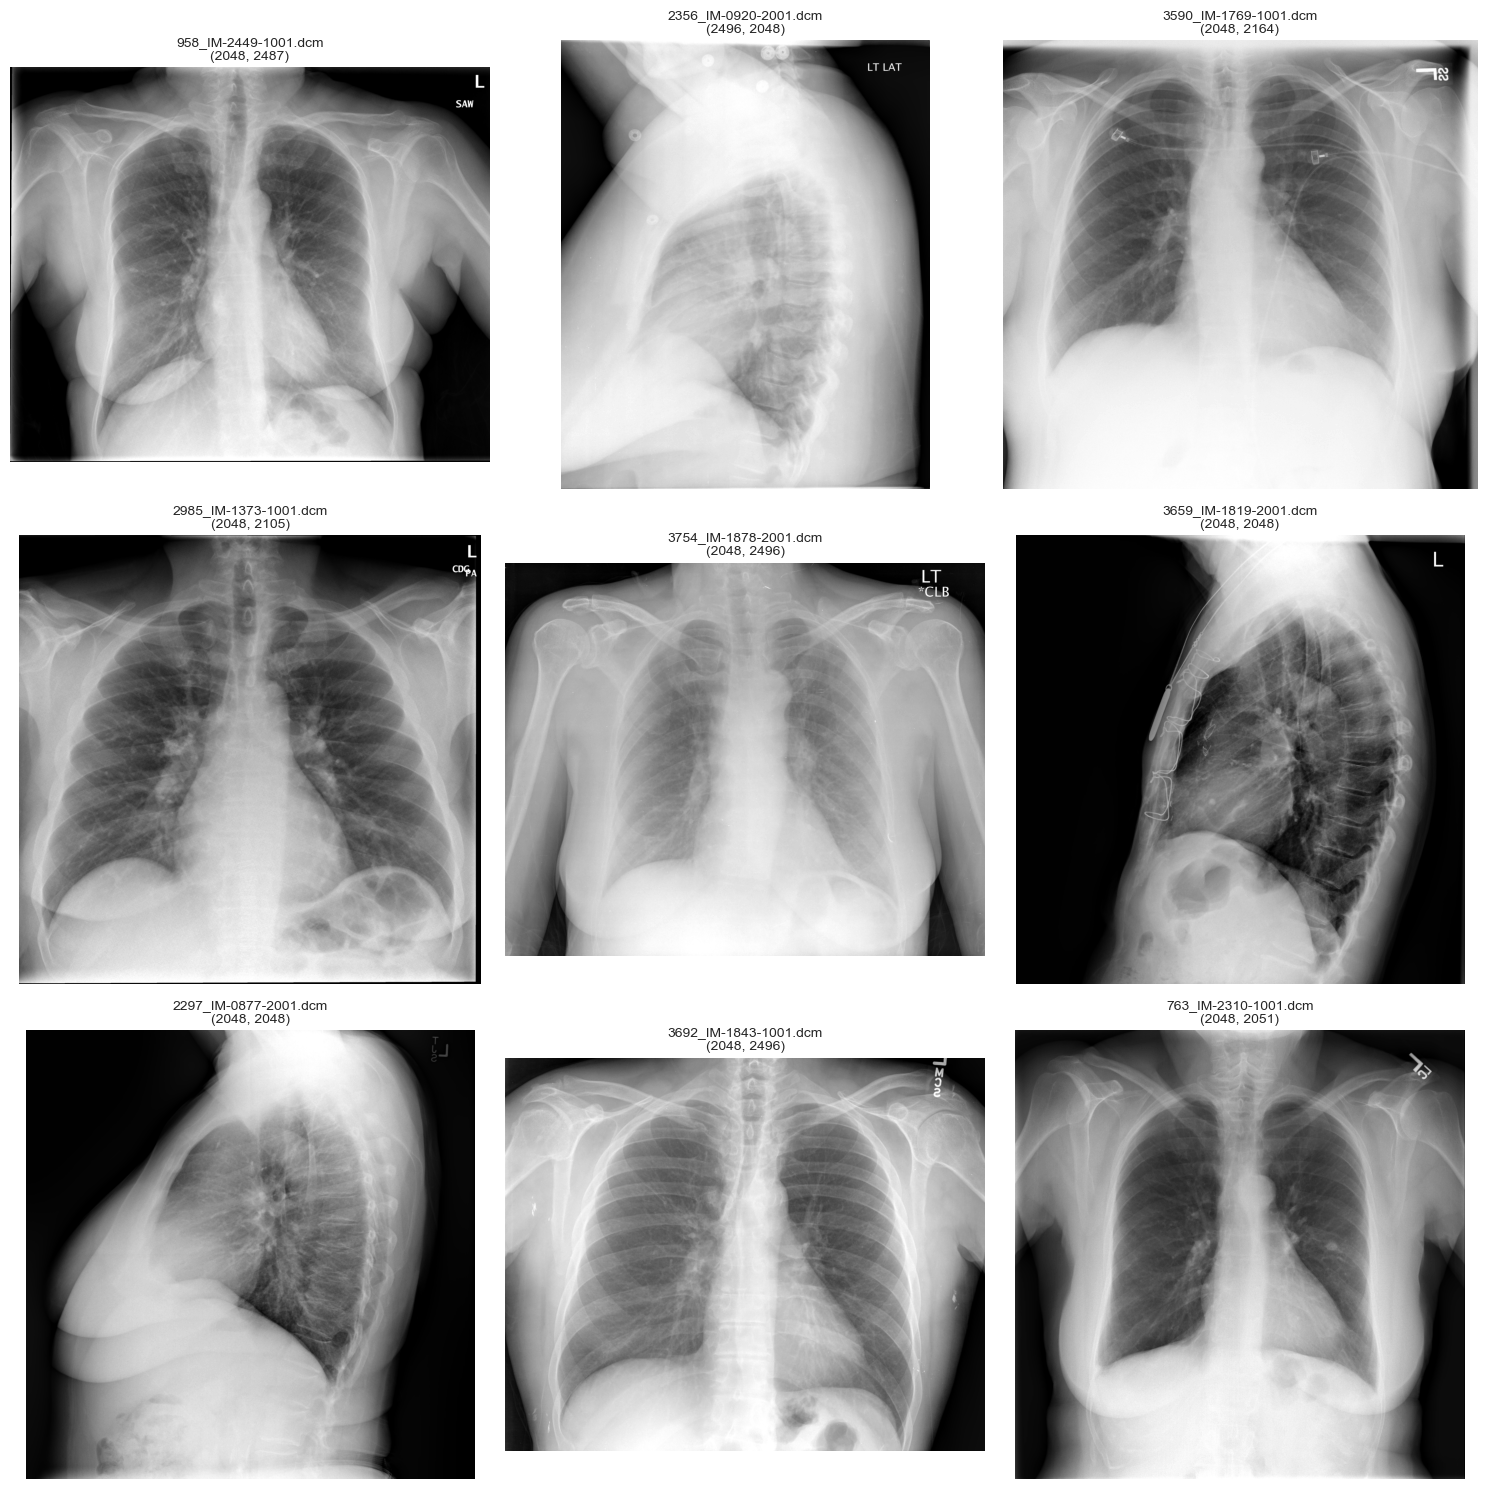

✅ 已顯示 9 張影像樣本
Analyzing 500 images...


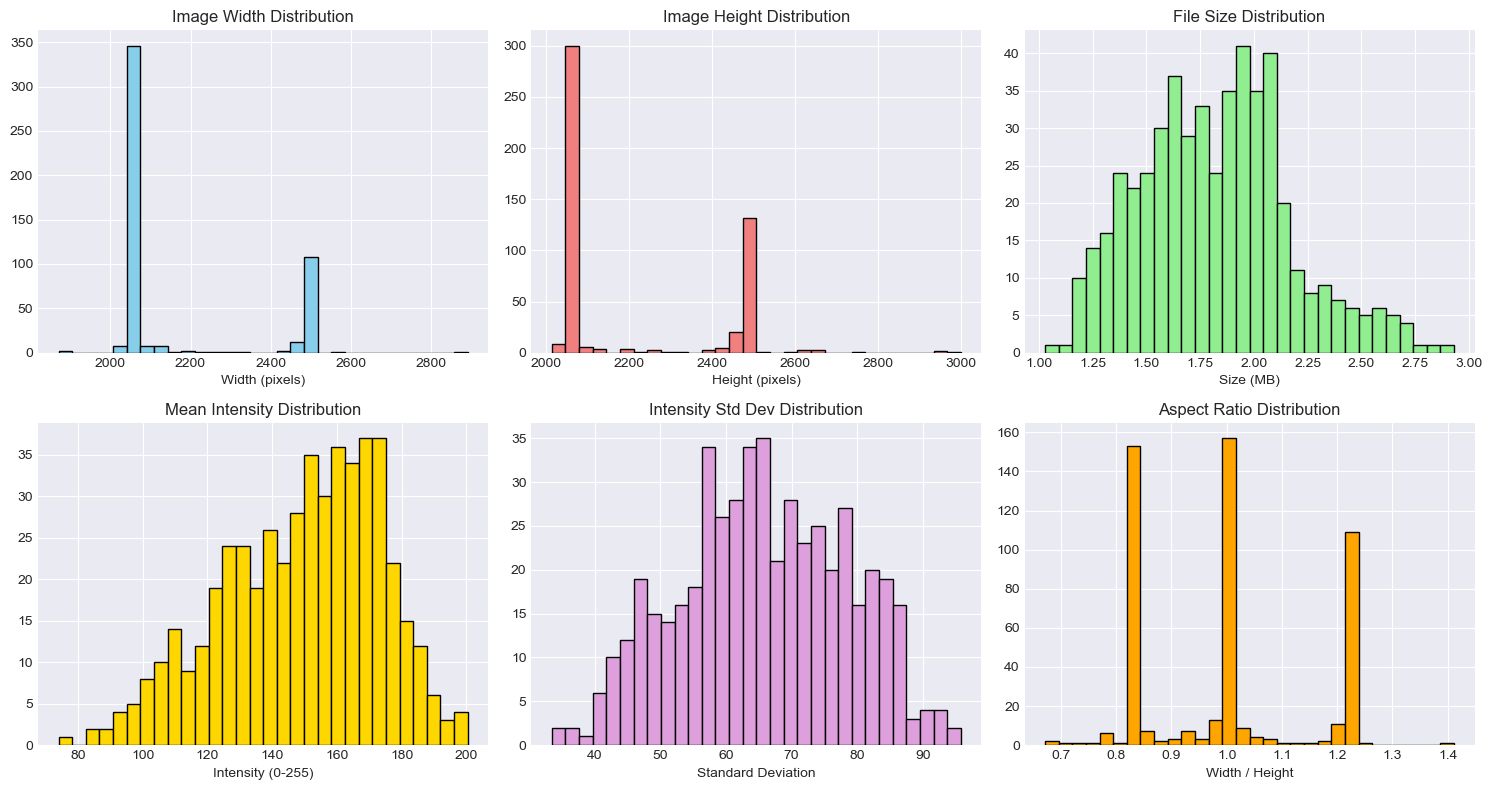

✅ Statistics saved to d:\master\DGM\final_project\cxr-counterfactual-explanation\results\tables
✅ 成功載入 3851 筆報告
   report_id  n_images                                          mesh_tags
0          1         2                                           [normal]
1          2         2  [Cardiomegaly/borderline, Pulmonary Artery/enl...
2          3         2                                           [normal]
3          4         2  [Pulmonary Disease, Chronic Obstructive, Bullo...
4          5         2  [Osteophyte/thoracic vertebrae/multiple/small,...


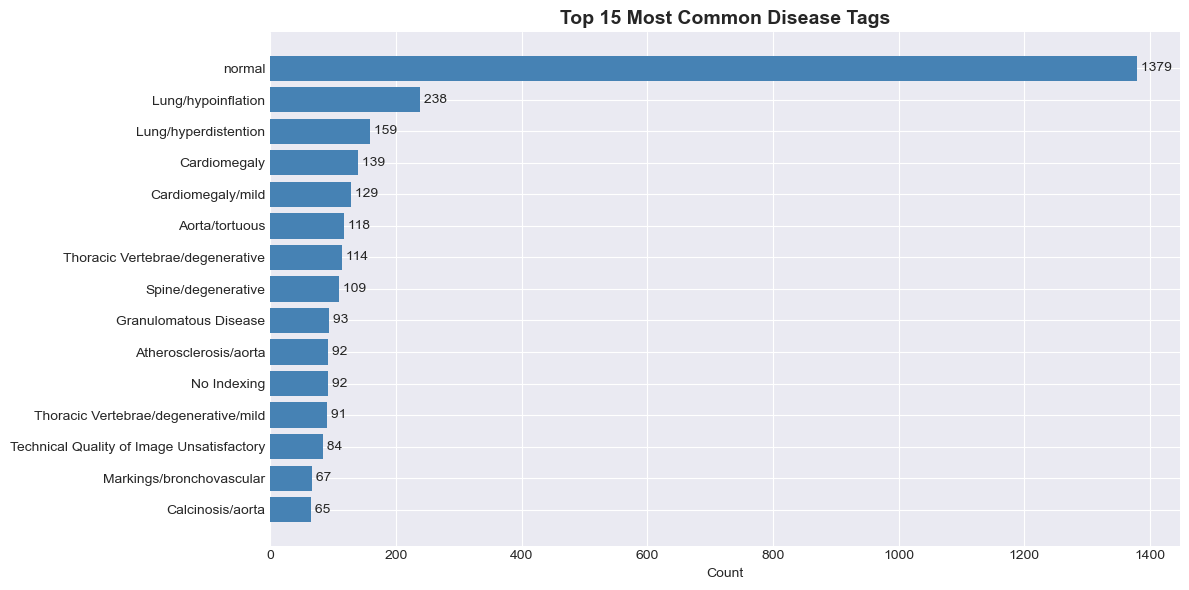

✅ Disease rankings saved to d:\master\DGM\final_project\cxr-counterfactual-explanation\results\tables
📊 目標疾病樣本統計：
Cardiomegaly: 414 個樣本
Infiltration: 326 個樣本
Pneumonia: 21 個樣本
Edema: 5 個樣本
Normal: 0 個樣本
✅ 已儲存標籤檔案至: d:\master\DGM\final_project\cxr-counterfactual-explanation\data\labels\raw_labels.csv
總共 7466 筆影像-報告配對
📊 資料探索總結

✅ 影像數量: 7470
✅ 報告數量: 3851

📐 影像解析度:
   平均寬度: 2163 pixels
   平均高度: 2210 pixels
   平均檔案大小: 1.82 MB

🏥 目標疾病樣本數:
   Cardiomegaly: 414
   Infiltration: 326
   Pneumonia: 21
   Edema: 5
   Normal: 0

🎯 下一步:
   1. 運行 02_data_preprocessing.ipynb 進行資料前處理
   2. 建立二元分類資料集（Normal vs. Cardiomegaly）
   3. 劃分訓練/驗證/測試集



In [1]:
# %% [markdown]
# # 資料探索與分析
# 
# 本 Notebook 用於探索 IU X-ray Dataset 的基本資訊、影像品質、標籤分布等。
# 
# ## 目標
# 1. 檢查資料集結構
# 2. 載入並視覺化影像
# 3. 分析放射科報告
# 4. 統計疾病標籤分布
# 5. 確定資料集劃分策略

# %%
import os
import glob
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import warnings
import sys
import datetime
from pathlib import Path

warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. 確保路徑定義正確 (修正縮排問題)
# ---------------------------------------------------------
if 'PROJECT_ROOT' not in locals():
    PROJECT_ROOT = Path.cwd().parent
    
print(f"專案根目錄: {PROJECT_ROOT}")

OUTPUT_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = OUTPUT_DIR / "figures"
LOGS_DIR = OUTPUT_DIR / "logs"
TABLES_DIR = OUTPUT_DIR / "tables"

for folder in [FIGURES_DIR, LOGS_DIR, TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 2. 除錯版 Logger (不再吞掉錯誤)
# ---------------------------------------------------------
class DualLogger:
    def __init__(self, filename, original_stdout):
        self.terminal = original_stdout
        self.log = open(filename, "w", encoding='utf-8-sig')
        self.is_dual_logger = True  # 標記自己是自定義的 Logger

    def write(self, message):
        # 1. 嘗試寫入螢幕 (VS Code)
        try:
            # 只有當 message 不為空時才寫入，減少閃爍
            if message:
                self.terminal.write(message)
                self.terminal.flush()
        except Exception as e:
            # 如果出錯，改用系統標準錯誤輸出印出來，不要吞掉！
            sys.__stderr__.write(f"\n[Logger Error]: {str(e)}\n")

        # 2. 寫入檔案
        try:
            self.log.write(message)
            self.log.flush()
        except Exception:
            pass

    def flush(self):
        try:
            self.terminal.flush()
            self.log.flush()
        except:
            pass

# ---------------------------------------------------------
# 3. 啟動機制 (精準還原，避免重複包裹)
# ---------------------------------------------------------
# 檢查目前的 stdout 是否已經是我們的 Logger，如果是，就還原成原本的 terminal
# 這樣可以防止重複按 "Run All" 時造成當機
current_stdout = sys.stdout

if hasattr(current_stdout, 'is_dual_logger') and current_stdout.is_dual_logger:
    # 發現是 DualLogger，還原回原本的 terminal
    sys.stdout = current_stdout.terminal
    print("🔄 已重置 Logger 狀態")

# 設定新的 Log 檔案
timestamp = datetime.datetime.now().strftime("%Y-%m-%d")
log_filename = LOGS_DIR / f"eda_report_{timestamp}.txt"

# 啟動新的 Logger
sys.stdout = DualLogger(log_filename, sys.stdout)

print("="*50)
print(f"✅ 自動記錄已啟動 (Debug Mode)")
print(f"📄 文字報告將儲存於: {log_filename}")
print(f"📊 統計圖表將儲存於: {FIGURES_DIR}")
print(f"📈 統計表格將儲存於: {TABLES_DIR}")
print("="*50)

# 設定繪圖樣式
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ 套件與 Logger 設定完成")

# %% [markdown]
# ## 1. 資料集路徑設定

# %%
# 專案根目錄
PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "data" / "raw"

# 確認路徑
print(f"專案根目錄: {PROJECT_ROOT}")
print(f"資料根目錄: {DATA_ROOT}")
print(f"資料目錄存在: {DATA_ROOT.exists()}")

# IU X-ray 資料集路徑（根據實際下載位置調整）
IMAGES_DIR = DATA_ROOT / "images"  
REPORTS_CSV = DATA_ROOT / "indiana_reports.csv"
PROJECTIONS_CSV = DATA_ROOT / "indiana_projections.csv"  

print(f"\n影像目錄: {IMAGES_DIR} (存在: {IMAGES_DIR.exists()})")
print(f"報告目錄: {REPORTS_CSV} (存在: {REPORTS_CSV.exists()})")
print(f"對應檔案: {PROJECTIONS_CSV} (存在: {PROJECTIONS_CSV.exists()})")

# %% [markdown]
# ## 2. 掃描影像檔案

# %%
# 搜尋所有 PNG 影像
image_files = list(IMAGES_DIR.glob("**/*.png"))

print(f"✅ 找到 {len(image_files)} 張影像")

# 顯示前 10 個檔案路徑
print("\n前 10 個影像檔案：")
for i, img_path in enumerate(image_files[:10], 1):
    print(f"{i}. {img_path.name}")

# 統計影像數量
if len(image_files) > 0:
    print(f"\n預期應該約有 7,470 張影像")
    print(f"實際掃描到: {len(image_files)} 張")
else:
    print("⚠️ 警告：未找到影像檔案，請確認資料集路徑是否正確")

# %% [markdown]
# ## 3. 載入並視覺化影像樣本

# %%
def load_and_display_images(image_paths, n_samples=9):
    """載入並顯示隨機影像樣本"""
    
    # 隨機選擇影像
    if len(image_paths) < n_samples:
        n_samples = len(image_paths)
    
    sample_paths = np.random.choice(image_paths, n_samples, replace=False)
    
    # 建立子圖
    n_rows = int(np.ceil(np.sqrt(n_samples)))
    n_cols = int(np.ceil(n_samples / n_rows))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))
    axes = axes.flatten() if n_samples > 1 else [axes]
    
    for idx, img_path in enumerate(sample_paths):
        try:
            # 載入影像
            img = Image.open(img_path).convert('L')  # 轉灰階
            img_array = np.array(img)
            
            # 顯示影像
            axes[idx].imshow(img_array, cmap='gray')
            axes[idx].set_title(f"{img_path.stem}\n{img_array.shape}", fontsize=10)
            axes[idx].axis('off')
            
        except Exception as e:
            axes[idx].text(0.5, 0.5, f"載入失敗\n{e}", 
                          ha='center', va='center', fontsize=8)
            axes[idx].axis('off')
    
    # 隱藏多餘的子圖
    for idx in range(n_samples, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "results" / "figures" / "sample_images.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ 已顯示 {n_samples} 張影像樣本")

# 視覺化影像
if len(image_files) > 0:
    load_and_display_images(image_files, n_samples=9)

# %% [markdown]
# ## 4. 分析影像解析度與品質

# %%
def analyze_image_properties(image_paths, n_samples=500):
    """Analyze image resolution, size, and intensity (English Version)"""
    
    print(f"Analyzing {min(n_samples, len(image_paths))} images...")
    
    properties = {
        'width': [], 'height': [], 'file_size_mb': [],
        'mean_intensity': [], 'std_intensity': []
    }
    
    # Random sampling
    sample_paths = np.random.choice(image_paths, min(n_samples, len(image_paths)), replace=False)
    
    for img_path in sample_paths:
        try:
            img = Image.open(img_path).convert('L')
            img_array = np.array(img)
            
            properties['width'].append(img_array.shape[1])
            properties['height'].append(img_array.shape[0])
            properties['file_size_mb'].append(img_path.stat().st_size / (1024**2))
            properties['mean_intensity'].append(np.mean(img_array))
            properties['std_intensity'].append(np.std(img_array))
            
        except Exception as e:
            continue
    
    df_props = pd.DataFrame(properties)
    
    # --- Visualization (English) ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # 1. Width
    axes[0, 0].hist(df_props['width'], bins=30, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Image Width Distribution')
    axes[0, 0].set_xlabel('Width (pixels)')
    
    # 2. Height
    axes[0, 1].hist(df_props['height'], bins=30, color='lightcoral', edgecolor='black')
    axes[0, 1].set_title('Image Height Distribution')
    axes[0, 1].set_xlabel('Height (pixels)')
    
    # 3. File Size
    axes[0, 2].hist(df_props['file_size_mb'], bins=30, color='lightgreen', edgecolor='black')
    axes[0, 2].set_title('File Size Distribution')
    axes[0, 2].set_xlabel('Size (MB)')
    
    # 4. Mean Intensity
    axes[1, 0].hist(df_props['mean_intensity'], bins=30, color='gold', edgecolor='black')
    axes[1, 0].set_title('Mean Intensity Distribution')
    axes[1, 0].set_xlabel('Intensity (0-255)')
    
    # 5. Std Intensity
    axes[1, 1].hist(df_props['std_intensity'], bins=30, color='plum', edgecolor='black')
    axes[1, 1].set_title('Intensity Std Dev Distribution')
    axes[1, 1].set_xlabel('Standard Deviation')
    
    # 6. Aspect Ratio
    aspect_ratios = df_props['width'] / df_props['height']
    axes[1, 2].hist(aspect_ratios, bins=30, color='orange', edgecolor='black')
    axes[1, 2].set_title('Aspect Ratio Distribution')
    axes[1, 2].set_xlabel('Width / Height')
    
    plt.tight_layout()
    
    # --- 關鍵修正：先存檔，再顯示 ---
    plt.savefig(FIGURES_DIR / "image_properties_dist.png", dpi=300)
    plt.show()
    
    # Save statistics table
    stats_df = df_props.describe()
    stats_df.to_csv(TABLES_DIR / "image_properties_stats.csv")
    print(f"✅ Statistics saved to {TABLES_DIR}")
    
    return df_props

# 執行分析
if len(image_files) > 0:
    df_image_props = analyze_image_properties(image_files, n_samples=500)

# %% [markdown]
# ## 5. 載入並分析放射科報告

# %%
def load_reports_from_csv(reports_path, projections_path):
    # 1. 讀取報告 CSV
    df_reports = pd.read_csv(reports_path)
    
    # 2. 讀取影像對應 CSV
    df_proj = pd.read_csv(projections_path)
    
    # 3. 欄位處理
    df_reports = df_reports.rename(columns={'uid': 'report_id', 'MeSH': 'mesh_tags'})
    df_reports['findings'] = df_reports['findings'].fillna('')
    df_reports['impression'] = df_reports['impression'].fillna('')
    
    # 解析 MeSH tags
    def parse_mesh(x):
        if pd.isna(x): return []
        return [t.strip() for t in x.split(';')]
    df_reports['mesh_tags'] = df_reports['mesh_tags'].apply(parse_mesh)
    
    # 4. 合併影像檔名
    image_map = df_proj.groupby('uid')['filename'].apply(list).to_dict()
    df_reports['image_ids'] = df_reports['report_id'].map(image_map)
    
    # 移除無影像的報告並計算數量
    df_reports = df_reports.dropna(subset=['image_ids'])
    df_reports['n_images'] = df_reports['image_ids'].apply(len)
    
    return df_reports

# 執行讀取
if REPORTS_CSV.exists() and PROJECTIONS_CSV.exists():
    df_reports = load_reports_from_csv(REPORTS_CSV, PROJECTIONS_CSV)
    print(f"✅ 成功載入 {len(df_reports)} 筆報告")
    print(df_reports[['report_id', 'n_images', 'mesh_tags']].head())
else:
    print("⚠️ 找不到 CSV 檔案")


# %% [markdown]
# ## 6. 疾病標籤統計

# %%
def analyze_mesh_tags(df_reports):
    """Analyze MeSH tag distribution (English Version)"""
    
    all_tags = []
    for tags in df_reports['mesh_tags']:
        all_tags.extend(tags)
    
    tag_counts = Counter(all_tags)
    df_tags = pd.DataFrame(tag_counts.items(), columns=['tag', 'count'])
    df_tags = df_tags.sort_values('count', ascending=False)
    
    # --- Visualization (English) ---
    fig, ax = plt.subplots(figsize=(12, 6))
    top_tags = df_tags.head(15)
    
    bars = ax.barh(range(len(top_tags)), top_tags['count'], color='steelblue')
    ax.set_yticks(range(len(top_tags)))
    ax.set_yticklabels(top_tags['tag'])
    ax.set_xlabel('Count')
    ax.set_title('Top 15 Most Common Disease Tags', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, 
                f' {int(width)}', ha='left', va='center', fontsize=10)
    
    plt.tight_layout()
    
    # --- 關鍵修正：先存檔，再顯示 ---
    plt.savefig(FIGURES_DIR / "disease_distribution_bar.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save ranking table
    df_tags.to_csv(TABLES_DIR / "disease_frequency_rank.csv", index=False)
    print(f"✅ Disease rankings saved to {TABLES_DIR}")
    
    return df_tags

# 執行分析
if 'df_reports' in locals():
    df_mesh_tags = analyze_mesh_tags(df_reports)

# %% [markdown]
# ## 7. 識別目標疾病類別

# %%
# 根據研究計畫，我們關注以下疾病：
TARGET_DISEASES = {
    'Cardiomegaly': ['Cardiomegaly', 'Cardiac', 'Heart'],  # 心臟肥大
    'Infiltration': ['Infiltration', 'Opacity'],  # 肺浸潤
    'Pneumonia': ['Pneumonia'],  # 肺炎
    'Edema': ['Edema', 'Pulmonary Edema'],  # 肺水腫
    'Normal': []  # 正常（無任何疾病標籤）
}

def identify_disease_samples(df_reports, target_diseases):
    """識別各疾病類別的樣本"""
    
    disease_samples = {disease: [] for disease in target_diseases.keys()}
    
    for idx, row in df_reports.iterrows():
        tags = [tag.lower() for tag in row['mesh_tags']]
        tags_str = ' '.join(tags)
        
        # 檢查是否屬於目標疾病
        matched = False
        for disease, keywords in target_diseases.items():
            if disease == 'Normal':
                continue
            
            for keyword in keywords:
                if keyword.lower() in tags_str:
                    disease_samples[disease].append(row['report_id'])
                    matched = True
                    break
            
            if matched:
                break
        
        # 如果沒有匹配任何疾病，視為正常
        if not matched and len(tags) == 0:
            disease_samples['Normal'].append(row['report_id'])
    
    # 統計
    print("📊 目標疾病樣本統計：")
    for disease, samples in disease_samples.items():
        print(f"{disease}: {len(samples)} 個樣本")
    
    return disease_samples

# 執行識別
if 'df_reports' in locals():
    disease_samples = identify_disease_samples(df_reports, TARGET_DISEASES)

# %% [markdown]
# ## 8. 儲存初步分析結果

# %%
# 建立標籤檔案（初步版本）
if 'df_reports' in locals():
    # 展開報告資料
    labels_data = []
    
    for idx, row in df_reports.iterrows():
        for img_id in row['image_ids']:
            labels_data.append({
                'image_id': img_id,
                'report_id': row['report_id'],
                'findings': row['findings'],
                'impression': row['impression'],
                'mesh_tags': '|'.join(row['mesh_tags'])
            })
    
    df_labels = pd.DataFrame(labels_data)
    
    # 儲存
    output_path = PROJECT_ROOT / "data" / "labels" / "raw_labels.csv"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df_labels.to_csv(output_path, index=False, encoding='utf-8-sig')
    
    print(f"✅ 已儲存標籤檔案至: {output_path}")
    print(f"總共 {len(df_labels)} 筆影像-報告配對")

# %% [markdown]
# ## 9. 總結與下一步

# %%
print("=" * 60)
print("📊 資料探索總結")
print("=" * 60)

if len(image_files) > 0:
    print(f"\n✅ 影像數量: {len(image_files)}")
    print(f"✅ 報告數量: {len(df_reports) if 'df_reports' in locals() else 'N/A'}")
    
    if 'df_image_props' in locals():
        print(f"\n📐 影像解析度:")
        print(f"   平均寬度: {df_image_props['width'].mean():.0f} pixels")
        print(f"   平均高度: {df_image_props['height'].mean():.0f} pixels")
        print(f"   平均檔案大小: {df_image_props['file_size_mb'].mean():.2f} MB")
    
    if 'disease_samples' in locals():
        print(f"\n🏥 目標疾病樣本數:")
        for disease, samples in disease_samples.items():
            print(f"   {disease}: {len(samples)}")
    
    print("\n🎯 下一步:")
    print("   1. 運行 02_data_preprocessing.ipynb 進行資料前處理")
    print("   2. 建立二元分類資料集（Normal vs. Cardiomegaly）")
    print("   3. 劃分訓練/驗證/測試集")
else:
    print("\n⚠️ 未找到影像檔案，請確認:")
    print("   1. 資料集是否已下載")
    print("   2. 資料集路徑是否正確")
    print("   3. 影像格式是否為 PNG")

print("\n" + "=" * 60)